In [1]:
# This notebook is for training the ATPC data with a 3D CNN
# Loads in preprocessed image files that have been pre-shuffled and voxelized

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import json
import time
from tqdm import tqdm
import lmdb
import pickle

import torch
import torch.nn as nn
import torch_scatter
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import multiprocessing as mp

import spconv.pytorch as spconv

from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

%matplotlib widget

In [2]:
# Check for CUDA (NVIDIA) or MPS (Apple)
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

NVIDIA GeForce RTX 2060
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB
Using device: cuda


In [3]:
# SpCov expects batch index to be ordered from 0 to batch_size -1
# When we run in batches, we get random indexes
# to fix this during training we shift the set so the batch index goes back from 0 to 1 
# i.e. we are using local batch index during training
def spconv_collate_fn(batch):
    coords_list, feats_list, bary_list, zmin_list, zmax_list, meta_list = zip(*batch)
    
    # Update the batch index (first column of coords)
    # Without this, spconv thinks every point in the batch belongs to 'Event 0'
    new_coords_list = []
    for i, coords in enumerate(coords_list):
        # Set the first column to the actual index in this specific batch
        coords[:, 0] = i 
        new_coords_list.append(coords)
        
    # Concatenate everything into single large tensors
    batch_coords = torch.cat(new_coords_list, dim=0)
    batch_feats  = torch.cat(feats_list, dim=0)
    bary_tensor = torch.stack(bary_list)
    zmin_tensor = torch.stack(zmin_list)
    zmax_tensor = torch.stack(zmax_list)
    
    # Structure meta list like 
    #{"event_id": [101, 102, 103, 104],"subType": ["TypeA", "TypeB", "TypeA", "TypeC"]}
    batch_meta = {
        key: [m[key] for m in meta_list] 
        for key in meta_list[0].keys()
    }
    
    return batch_coords, batch_feats, bary_tensor, zmin_tensor, zmax_tensor, batch_meta


In [4]:
def GetSpatialShape(df, max_x, max_y, max_z):
        
    if (max(df['z']) > max_z): max_z = max(df['z'])
    if (max(df['y']) > max_y): max_y = max(df['y'])
    if (max(df['x']) > max_x): max_x = max(df['x'])

    # Convert to voxel units and add a buffer
    global_max_coords = np.array([max_z, max_y, max_x])
    spatial_shape = np.ceil(global_max_coords).astype(int) + 1

    # Round up to a multiple of 8 or 16
    # This ensures that stride-2 layers divide cleanly
    input_data_shape = [ int(((s + 15) // 16) * 16) for s in spatial_shape]
    return input_data_shape, max_x, max_y, max_z

def center_event(coords, spatial_shape):
    # coords: [N, 3] (z, y, x)
    # spatial_shape: [max_z, max_y, max_x]
    
    barycenter = np.mean(coords, axis=0)
    
    # The middle of the detector
    grid_center = np.array(spatial_shape) // 2
    
    # Shift-> Detector-center
    # Round to the nearest integer to stay on the grid
    shifted_coords = np.round(coords - barycenter + grid_center).astype(np.int16)
    
    # Clip to ensure no points fell off the grid
    shifted_coords[:, 0] = np.clip(shifted_coords[:, 0], 0, spatial_shape[0] - 1)
    shifted_coords[:, 1] = np.clip(shifted_coords[:, 1], 0, spatial_shape[1] - 1)
    shifted_coords[:, 2] = np.clip(shifted_coords[:, 2], 0, spatial_shape[2] - 1)
    
    return shifted_coords


def MakeLMBD(file_paths, data_sample):

    # lmdb_path = f"/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples//CNN_files_zpos/CNN_{data_sample}_events.lmdb"
    # meta_file = f"/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples//CNN_files_zpos/CNN_{data_sample}_meta.json"
    
    lmdb_path = f"CNN_{data_sample}_events_test.lmdb"
    meta_file = f"CNN_{data_sample}_meta_test.json"
    
    subtype_counts = Counter()
    max_z = 0
    max_y = 0
    max_x = 0
    input_data_shape = [0, 0, 0]
    
    # If we have the file already then we dont need to run again. 
    if os.path.exists(lmdb_path):
        print("CNN LMDB files exist, so returning...")
        return
    
    env = lmdb.open(lmdb_path, map_size=1e12)  # adjust if needed

    mapping = {"Bi": 0, "Tl": 1, "single": 2, "0nubb": 3}
    
    input_data_shape = [784, 784, 784]

    idx = 0

    with env.begin(write=True) as txn:
        for file_path in file_paths[0:4]:
            print(f"Processing {file_path}...")
            shard = torch.load(file_path, map_location="cpu")

            for df_event in tqdm(shard):
                
                # A loop over the unique groups
                for g_df in df_event.unique_group_id.unique():
                
                    df = df_event[df_event.unique_group_id == g_df]
                
                    coords = df[['z', 'y', 'x']].values.astype(np.int16)
                    
                    # Shift the coordinates so the barycenter is in the middle of the grid
                    coords = center_event(coords, input_data_shape)
                    
                    # Ensure we have a vector that includes the batch index of zeros.
                    spconv_coords = np.zeros((coords.shape[0], 4), dtype=np.int16)
                    spconv_coords[:, 1:] = coords
                    
                    energy = df[['energy']].values.astype(np.float32)

                    label = int(df.label.iloc[0])
                    subtype = int(mapping[df.subType.iloc[0]])
                    subtype_counts.update([subtype])
                    event_id = df.event_id.iloc[0]
                    barycentre = df[['z']].mean().astype(np.float32)
                    e_tot = df['energy'].sum().astype(np.float32)
                    zmin = df['z'].min().astype(np.float32)
                    zmax = df['z'].max().astype(np.float32)
                    ugroup_id = g_df

                    event = {
                        "coords": spconv_coords,
                        "energy": energy,
                        "label": label,
                        "subtype": subtype,
                        "event_id": event_id,
                        "ugroup_id": ugroup_id,
                        "barycentre": barycentre,
                        "e_tot": e_tot,
                        "zmin": zmin,
                        "zmax": zmax
                    }

                    key = f"{idx:09d}".encode()
                    value = pickle.dumps(event)

                    txn.put(key, value)
                    idx += 1
                    
                    # input_data_shape, max_x, max_y, max_z = GetSpatialShape(df, max_x, max_y, max_z)
        
        # Save the metadata too
        print(f"Saving metadata to {meta_file}...")
        print(dict(subtype_counts))
        
        print(input_data_shape)
        with open(meta_file, 'w') as f:
            json.dump({
                'subtype_counts': dict(subtype_counts),
                'input_data_shape': [784, 784, 784]
            }, f)

    env.close()
    print(f"Stored {idx} events")

MakeLMBD(sorted(glob.glob("/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples//CNN_files/ATPC_CNN_chunk_train_*.pt")), "Train")
MakeLMBD(sorted(glob.glob("/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples//CNN_files/ATPC_CNN_chunk_val_*.pt")),   "Validation")
MakeLMBD(sorted(glob.glob("/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples//CNN_files/ATPC_CNN_chunk_test_*.pt")),  "Test")

CNN LMDB files exist, so returning...
CNN LMDB files exist, so returning...
CNN LMDB files exist, so returning...


In [5]:
class LMDBEventDataset(Dataset):
    def __init__(self, lmdb_path, data_sample):
        self.env = lmdb.open(lmdb_path, readonly=True, lock=False)
        
        # Load in the metadata
        meta_file = f"/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples//CNN_files_zpos/CNN_{data_sample}_meta.json"
        # meta_file = f"CNN_{data_sample}_meta_test.json"
        
        print(f"Loading metadata from cache: {meta_file}")
        with open(meta_file, 'r') as f:
            cache_data = json.load(f)
            raw_counts = cache_data['subtype_counts']
            self.subtype_counts = Counter({int(k): v for k, v in raw_counts.items()})
            self.input_data_shape = cache_data["input_data_shape"]
            
        self.print_scale_factors(data_sample)
        print("The input shape is: ")
        print(self.input_data_shape)
        
        with self.env.begin() as txn:
            self.length = txn.stat()['entries']

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        with self.env.begin() as txn:
            key = f"{idx:09d}".encode()
            data = pickle.loads(txn.get(key))
            
        return (
            torch.from_numpy(data["coords"]).int(),
            torch.from_numpy(data["energy"]).float(),
            torch.tensor(data["barycentre"]).float(),
            torch.tensor(data["zmin"]).float(),
            torch.tensor(data["zmax"]).float(),
            {"subType": data["subtype"], "event_id": data["event_id"], "ugroup_id": data["ugroup_id"], "e_tot": data["e_tot"]}
        )
        
    def print_scale_factors(self, data_sample):
        sig = self.subtype_counts[0]
        bi  = self.subtype_counts[1]
        tl  = self.subtype_counts[2]
        sn  = self.subtype_counts[3]
        total_bkg = bi + tl + sn

        print(f"\n--- {data_sample} Dataset Summary ---")
        print(f"Signal (0nubb): {sig}")
        print(f"Background: {total_bkg}")
        print(f"Thalium: {tl}")
        print(f"Bismuth: {bi}")
        print(f"Single: {sn}")

train_dataset = LMDBEventDataset("/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples//CNN_files_zpos/CNN_Train_events.lmdb", "Train")
val_dataset   = LMDBEventDataset("/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples//CNN_files_zpos/CNN_Validation_events.lmdb", "Validation")
test_dataset  = LMDBEventDataset("/media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples//CNN_files_zpos/CNN_Test_events.lmdb", "Test")

# train_dataset = LMDBEventDataset("CNN_Train_events_test.lmdb", "Train")
# val_dataset   = LMDBEventDataset("CNN_Validation_events_test.lmdb", "Validation")
# test_dataset  = LMDBEventDataset("CNN_Test_events_test.lmdb", "Test")


Loading metadata from cache: /media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples//CNN_files_zpos/CNN_Train_meta.json

--- Train Dataset Summary ---
Signal (0nubb): 365940
Background: 867237
Thalium: 243149
Bismuth: 415033
Single: 209055
The input shape is: 
[784, 784, 784]
Loading metadata from cache: /media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples//CNN_files_zpos/CNN_Validation_meta.json

--- Validation Dataset Summary ---
Signal (0nubb): 103595
Background: 248154
Thalium: 69395
Bismuth: 119247
Single: 59512
The input shape is: 
[784, 784, 784]
Loading metadata from cache: /media/argon/HardDrive_8TB/Krishan/ATPC/ML_samples//CNN_files_zpos/CNN_Test_meta.json

--- Test Dataset Summary ---
Signal (0nubb): 52073
Background: 124028
Thalium: 34557
Bismuth: 59438
Single: 30033
The input shape is: 
[784, 784, 784]


In [6]:
BATCH_SIZE = 256
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=5, pin_memory=True, persistent_workers=True, prefetch_factor=2, collate_fn=spconv_collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=5, pin_memory=True, persistent_workers=True, prefetch_factor=2, collate_fn=spconv_collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=5, pin_memory=True, persistent_workers=True, prefetch_factor=2, collate_fn=spconv_collate_fn)

tensor([598.3333]) tensor(597.) tensor(600.)
{'subType': 1, 'event_id': 2054001473, 'ugroup_id': 49791, 'e_tot': 0.093461275}


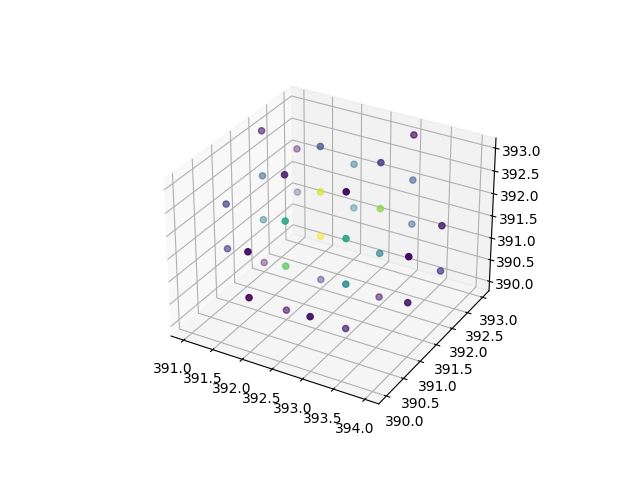

In [7]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# Get df 0, coords, x
# train_dataset[0][0][:,1]

eid = 10

coords, feats, barycenter, zmin, zmax, meta  = train_dataset[eid]
print(barycenter, zmin, zmax)

print(train_dataset[eid][5]);

# print(min(train_dataset[eid][0][:,3]));

ax.scatter(train_dataset[eid][0][:,1], train_dataset[eid][0][:,2], train_dataset[eid][0][:,3], c = train_dataset[eid][1][:,0]);

In [8]:

class SparseEventNet(nn.Module):
    def __init__(self, input_channels, num_classes, spatial_shape):
        super(SparseEventNet, self).__init__()
        self.spatial_shape = spatial_shape
        
        self.net = spconv.SparseSequential(
            # Block 1
            spconv.SubMConv3d(input_channels, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            
            # Block 2 
            spconv.SubMConv3d(32, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            # Block 3: Downsample (Stride 2)
            spconv.SparseConv3d(32, 64, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            # Block 4
            spconv.SubMConv3d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            
            # Block 5: Final Downsample to a small feature map
            spconv.SparseConv3d(64, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm1d(128),
            nn.ReLU(),
        )

        # Final Dense Layer to cast to number of classes
        self.fc = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            # nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            # nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            # nn.Dropout(0.2),
            nn.Linear(32, num_classes)
        )

    def forward(self, features, coords, batch_size):
        
        x = spconv.SparseConvTensor(features, coords, self.spatial_shape, batch_size)
        x = self.net(x)
        out = self.global_pool_scatter(x)
        
        return self.fc(out)

    # Global Pooling
    # Take the features of the remaining sparse points and average+get max (per image)
    # x.features is a tensor of [Total_Active_Points, features]
    # We need to average these per-image using the batch indices in x.indices
    def global_pool(self, x):
        features = x.features
        batch_ids = x.indices[:, 0]
        pooled_feats = []
        for i in range(x.batch_size):
            mask = (batch_ids == i)
            if mask.any():
                pooled_feats.append(torch.cat([
                    features[mask].mean(dim=0),
                    features[mask].max(dim=0)[0]
                ]))
            # Safetey block in case a processed image is empty at this stage (no active voxels)
            # In this case return array of zeros. 
            else:
                pooled_feats.append(torch.zeros(features.shape[1]).to(features.device))
        return torch.stack(pooled_feats)
    
    def global_pool_scatter(self, x):
        # x is SparseConvTensor
        features = x.features
        batch_ids = x.indices[:, 0].long()
        num_batches = x.batch_size
        
        # Vectorized Mean
        sum_pooled = torch.zeros(num_batches, features.shape[1], device=features.device)
        sum_pooled.scatter_add_(0, batch_ids.unsqueeze(1).expand(-1, features.shape[1]), features)
        
        counts = torch.zeros(num_batches, 1, device=features.device)
        counts.scatter_add_(0, batch_ids.unsqueeze(1), torch.ones_like(batch_ids, dtype=torch.float).unsqueeze(1))
        mean_pooled = sum_pooled / counts.clamp(min=1)

        # Vectorized Max 
        max_pooled = torch.zeros(num_batches, features.shape[1], device=features.device)
        max_pooled = max_pooled.scatter_reduce(
            0, 
            batch_ids.unsqueeze(1).expand(-1, features.shape[1]), 
            features, 
            reduce="amax", 
            include_self=False
        )
        
        return torch.cat([mean_pooled, max_pooled], dim=1)

In [9]:
# Create the model
model = SparseEventNet(input_channels=1, num_classes=3, spatial_shape=train_dataset.input_data_shape).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5) #  This will help adjust the learning rate
criterion = nn.MSELoss().to(device) # can add this so it relaxes the loss criterion a bit. label_smoothing=0.1

total_batches = len(train_loader)
report_interval = max(1, total_batches // 5) # report every 20% batch processed
print("total batches", total_batches, "| report_interval", report_interval)

min_epoch = 0
last_epoch=0
history_df = pd.DataFrame()
best_val_loss=1e20

VERSION = 5 # This is with fix to the voxel function

load_state = True
if (load_state):
    history_df = pd.read_csv(f"../CNN_files_zpos/CNN_train_history_v{VERSION}.csv")
    print("Loading Model State from file!")
    display(history_df)
    
    last_epoch = int(max(history_df.epoch)) # Carry on from the last epoch
    checkpoint = torch.load(f'../CNN_files_zpos/CNN_v{VERSION}_epoch{last_epoch}.pt', map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    min_epoch     = checkpoint['epoch']+1
    best_val_loss = checkpoint['loss']

# ---------------------------------------------------------------------------------------------------
EPOCHS = 5

for epoch in range(min_epoch, min_epoch+EPOCHS):
    print("Running Epoch ", epoch)
    t0 = time.time()

    # ---- train ---------------------------------------------------------------------------------
    model.train()
    train_loss = 0
    i = 0
    for coords, feats, barycenter, zmin, zmax, meta in train_loader:
        coords, feats, barycenter, zmin, zmax = coords.to(device), feats.to(device), barycenter.to(device), zmin.to(device), zmax.to(device)
        
        # Three targets now: barycenter, zmin, zmax
        targets = torch.stack([barycenter.view(-1), zmin.view(-1), zmax.view(-1)], dim=1)
        # targets = barycenter
        targets = targets/784

        optimizer.zero_grad()
        logits = model(feats, coords, barycenter.shape[0]) # Z prediction
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
        # Print every 10%
        if (i + 1) % report_interval == 0:
            percent_done = (i + 1) / total_batches * 100
            print(f"Progress Epoch {epoch}: {percent_done:.0f}% ({i + 1}/{total_batches} batches)")
            
        i = i+1

    # ---- validate ---------------------------------------------------------------------------------
    model.eval()
    all_preds = []
    all_labels = []
    val_loss = 0
    with torch.no_grad():
        for coords, feats, barycenter, zmin, zmax, meta in val_loader:
            
            coords, feats, barycenter, zmin, zmax = coords.to(device), feats.to(device), barycenter.to(device), zmin.to(device), zmax.to(device)
            targets = torch.stack([barycenter.view(-1), zmin.view(-1), zmax.view(-1)], dim=1)
            # targets = barycenter
            targets = targets/784
            preds = model(feats, coords, barycenter.shape[0])
            loss = criterion(preds, targets)
            val_loss += loss.item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(targets.cpu().numpy())
    
    # Adjust the learning rate scheduler
    # scheduler.step(val_loss)
    
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': val_loss,
    }
    
    torch.save(checkpoint, f'../CNN_files_zpos/CNN_v{VERSION}_epoch{epoch}.pt')
    
    # Just useful to print
    if val_loss < best_val_loss:
        print("Model improved! Saving...")
        best_val_loss = val_loss
    
    t1 = time.time()
    epoch_time = (t1 - t0)/60.
    print("Epoch time was:", epoch_time, "m")
    
    
    # Save the history of the training -----------------------------------------------------------------------------
    # Saving the information from the training
    metrics = {
        'epoch': epoch,
        'epoch_time': float(epoch_time),
        'train_loss': float(train_loss),
        'val_loss': float(val_loss)
        
    }
    print(metrics)
    
    try:
        history_df = pd.read_csv(f"../CNN_files_zpos/CNN_train_history_v{VERSION}.csv")
    except:
        history_df = pd.DataFrame()
        
    history_df_current = pd.DataFrame([metrics])
    history_df = pd.concat( [history_df, history_df_current])
    history_df.to_csv(f'../CNN_files_zpos/CNN_train_history_v{VERSION}.csv', index=False)
    
    print(f"Epoch {epoch+1}/{min_epoch+EPOCHS} | Train Loss: {train_loss:.3f} | Val Loss: {val_loss:.3f}")
    last_epoch=epoch


display(history_df)


total batches 4818 | report_interval 963
Loading Model State from file!


,epoch,epoch_time,train_loss,val_loss
0,0,8.543061,20.290976,3.006283
1,1,8.184809,13.221677,4.615052
2,2,8.175486,12.427596,5.917459
3,3,8.183193,11.876432,3.741300


Running Epoch  4


/tmp/ipykernel_1817716/3000093998.py:92: UserWarning: scatter_reduce() is in beta and the API may change at any time. (Triggered internally at ../aten/src/ATen/native/TensorAdvancedIndexing.cpp:1615.)
  max_pooled = max_pooled.scatter_reduce(


Progress Epoch 4: 20% (963/4818 batches)
Progress Epoch 4: 40% (1926/4818 batches)
Progress Epoch 4: 60% (2889/4818 batches)
Progress Epoch 4: 80% (3852/4818 batches)
Progress Epoch 4: 100% (4815/4818 batches)
Epoch time was: 8.681251764297485 m
{'epoch': 4, 'epoch_time': 8.681251764297485, 'train_loss': 11.383829328697175, 'val_loss': 3.8839611227158457}
Epoch 5/9 | Train Loss: 11.384 | Val Loss: 3.884
Running Epoch  5
Progress Epoch 5: 20% (963/4818 batches)
Progress Epoch 5: 40% (1926/4818 batches)
Progress Epoch 5: 60% (2889/4818 batches)
Progress Epoch 5: 80% (3852/4818 batches)
Progress Epoch 5: 100% (4815/4818 batches)
Epoch time was: 8.265702116489411 m
{'epoch': 5, 'epoch_time': 8.265702116489411, 'train_loss': 11.099867027893197, 'val_loss': 6.30872816639021}
Epoch 6/9 | Train Loss: 11.100 | Val Loss: 6.309
Running Epoch  6
Progress Epoch 6: 20% (963/4818 batches)
Progress Epoch 6: 40% (1926/4818 batches)
Progress Epoch 6: 60% (2889/4818 batches)
Progress Epoch 6: 80% (3852/4

,epoch,epoch_time,train_loss,val_loss
0,0,8.543061,20.290976,3.006283
1,1,8.184809,13.221677,4.615052
2,2,8.175486,12.427596,5.917459
3,3,8.183193,11.876432,3.741300
4,4,8.681252,11.383829,3.883961
5,5,8.265702,11.099867,6.308728
6,6,8.260474,11.347843,4.634907
7,7,8.262054,11.032425,2.890754
0,8,8.264795,10.904067,2.979757


In [10]:
model = SparseEventNet(input_channels=1, num_classes=1, spatial_shape=train_dataset.input_data_shape).to(device)

criterion = nn.MSELoss().to(device)

VERSION = 4

history_df = pd.read_csv(f"../CNN_files_zpos/CNN_train_history_v{VERSION}.csv")
print("Loading Model State from file!")
display(history_df)

last_epoch = int(max(history_df.epoch)) # Carry on from the last epoch
last_epoch = np.argmin(history_df.val_loss)
print(np.argmin(history_df.val_loss))


checkpoint = torch.load(f'../CNN_files_zpos/CNN_v{VERSION}_epoch{last_epoch}.pt', map_location=device)

# 4. Restore the states
model.load_state_dict(checkpoint['model_state_dict'])
epoch = checkpoint['epoch']
loss = checkpoint['loss']


Loading Model State from file!


,epoch,epoch_time,train_loss,val_loss
0,0,8.524237,34.356358,11.668147
1,1,8.161413,20.070757,17.131653
2,2,8.145452,18.890949,6.941924
3,3,8.144050,18.518781,10.948845
4,4,8.135429,18.062875,9.884943


2


RuntimeError: Error(s) in loading state_dict for SparseEventNet:
	Missing key(s) in state_dict: "fc.2.weight", "fc.2.bias", "fc.4.weight", "fc.4.bias". 
	Unexpected key(s) in state_dict: "fc.9.weight", "fc.9.bias", "fc.3.weight", "fc.3.bias". 
	size mismatch for fc.6.weight: copying a param with shape torch.Size([32, 64]) from checkpoint, the shape in current model is torch.Size([1, 32]).
	size mismatch for fc.6.bias: copying a param with shape torch.Size([32]) from checkpoint, the shape in current model is torch.Size([1]).

In [ ]:
def CalcModelMetrics(data_loader, name ,device ):
    
    model.eval()
    all_preds_bary, all_true_bary = [], []
    all_preds_zmin, all_true_zmin = [], []
    all_preds_zmax, all_true_zmax = [], []
    
    all_subTypes = []
    all_event_ids = []
    all_e_tot = []
    val_loss = 0
    with torch.no_grad():
        
        for coords, feats, barycenter, zmin, zmax, meta in data_loader:
            
            coords, feats, barycenter, zmin, zmax = coords.to(device), feats.to(device), barycenter.to(device), zmin.to(device), zmax.to(device)
            targets = torch.stack([barycenter.view(-1), zmin.view(-1), zmax.view(-1)], dim=1)
            
            # targets = barycenter
            targets = targets/784
            
            preds = model(feats, coords, barycenter.shape[0])
            loss = criterion(preds, targets)
            val_loss += loss.item()
            
            all_preds_bary.extend(preds[:, 0].cpu().numpy()*784)
            all_true_bary.extend(targets[:, 0].cpu().numpy()*784)
            all_preds_zmin.extend(preds[:, 1].cpu().numpy()*784)
            all_true_zmin.extend(targets[:, 1].cpu().numpy()*784)
            all_preds_zmax.extend(preds[:, 2].cpu().numpy()*784)
            all_true_zmax.extend(targets[:, 2].cpu().numpy()*784)
            
            all_subTypes.extend(meta["subType"])
            all_event_ids.extend(meta["event_id"])
            all_e_tot.extend(meta["e_tot"])
        
    df_zpos = pd.DataFrame({"event_id": all_event_ids, "bary_pred": all_preds_bary, "bary_true": all_true_bary, 
                            "zmin_pred": all_preds_zmin, "zmin_true": all_true_zmin, 
                            "zmax_pred": all_preds_zmax, "zmax_true": all_true_zmax, 
                            "subTypes" : all_subTypes, "e_tot": all_e_tot})
    
    # df_zpos = pd.DataFrame({"event_id": all_event_ids, "bary_pred": all_preds_bary, "bary_true": all_true_bary, 
    #                         "subTypes" : all_subTypes, "e_tot": all_e_tot})

    return df_zpos

# df_zpos_train = CalcModelMetrics(train_loader, "Train     ", device)
df_zpos_val   = CalcModelMetrics(val_loader,   "Validation", device)
df_zpos_test  = CalcModelMetrics(test_loader,  "Test      ", device)
# df_zpos_all = pd.concat([df_zpos_train, df_zpos_val, df_zpos_test])
df_zpos_all = pd.concat([df_zpos_val, df_zpos_test])

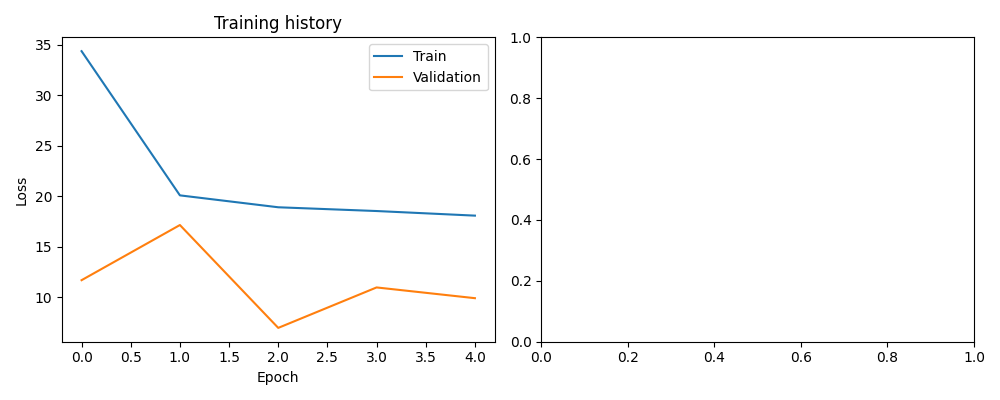

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

axs[0].plot(history_df.train_loss, label='Train')
axs[0].plot(history_df.val_loss, label='Validation')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].set_title('Training history')
plt.tight_layout()

In [ ]:
df_zpos_all.head()

,event_id,bary_pred,bary_true,subTypes,e_tot
0,22029143,361.254913,335.563232,2,0.611538
1,22029143,478.838104,461.210541,2,5.484055
2,361706,518.174805,511.079407,3,6.188530
3,30450000558,319.123230,307.822235,0,5.617814
4,30450000558,357.891876,308.652161,0,0.067998


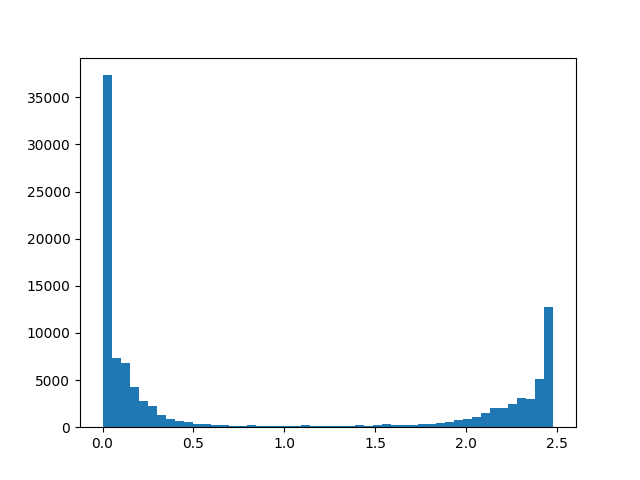

In [ ]:
plt.figure()
plt.hist(df_zpos_all.e_tot*0.4, bins=50);

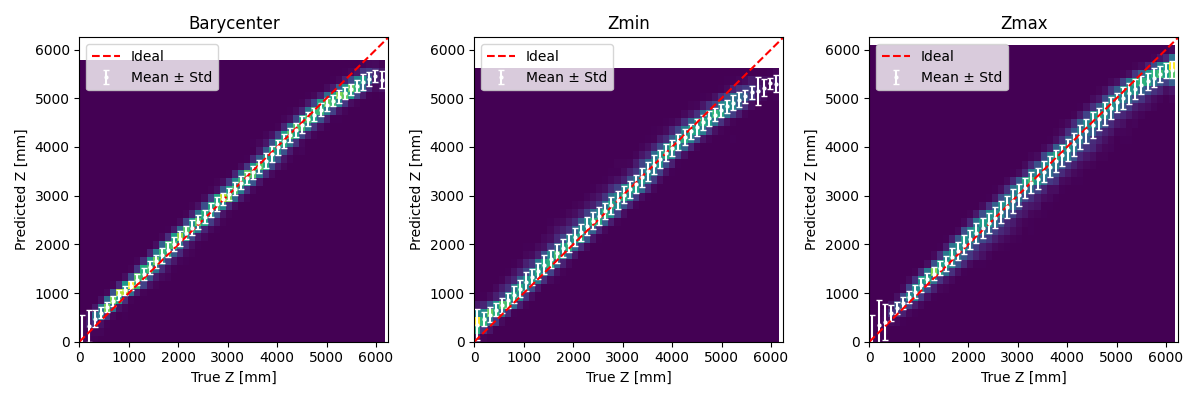

In [ ]:
from scipy.stats import binned_statistic
# plt.figure()
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))

def plot_pred_vs_true(x_data, y_data, ax, title):
    
    x_data = x_data*8
    y_data = y_data*8
    
    ax.hist2d(x_data, y_data, bins=50, cmap='viridis')
    # ax.colorbar(label='Counts')

    bin_means, bin_edges, _ = binned_statistic(x_data, y_data, statistic='mean', bins=50)
    bin_stds, _, _ = binned_statistic(x_data, y_data, statistic='std', bins=50)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    mask = ~np.isnan(bin_means)

    ax.errorbar(bin_centers[mask], bin_means[mask], yerr=bin_stds[mask], fmt='o',color='white',ecolor='white',markersize=2,capsize=2,label='Mean ± Std')
    ax.legend()
    ax.set_xlabel("True Z [mm]")
    ax.set_ylabel("Predicted Z [mm]")
    ax.set_title(title)
    ax.set_xlim(0,6250)
    ax.set_ylim(0,6250)
    
    x = np.linspace(0,6250,100)
    y = x
    ax.plot(x, y, color='red', linestyle='--', label='Ideal')
    ax.legend()
    
    return bin_means[mask], bin_stds[mask]

df_zpos_all_filt = df_zpos_all
df_zpos_all_filt = df_zpos_all[df_zpos_all.e_tot*0.4 > 1] 

bary_mean, bary_std = plot_pred_vs_true(df_zpos_all_filt.bary_true, df_zpos_all_filt.bary_pred, axs[0], "Barycenter")
zmin_mean, zmin_std = plot_pred_vs_true(df_zpos_all_filt.zmin_true, df_zpos_all_filt.zmin_pred, axs[1], "Zmin")
zmax_mean, zmax_std = plot_pred_vs_true(df_zpos_all_filt.zmax_true, df_zpos_all_filt.zmax_pred, axs[2], "Zmax")
plt.tight_layout()

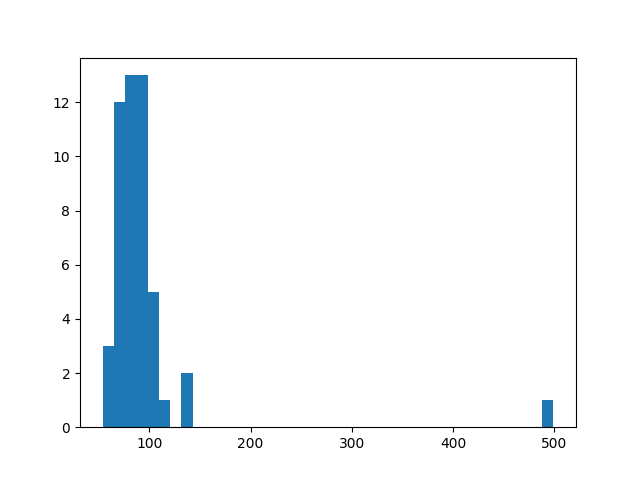

In [ ]:
plt.figure()
plt.hist(bary_std, bins=40);